# FSSK Exact Validation

## Overview

A **Functional State-Space Kernel** (FSSK) is a positive-definite kernel on path space defined via a
state-space system driven by the increments of the input path $X : [0,T] \to \mathbb{R}^d$.
For truncation level $N$ and Volterra order $q$, the kernel evaluation amounts to computing
the **state-space signature** (SSS)

$$
\mathrm{SSS}(X)^n \;=\; \sum_{\alpha \in \mathcal{A}_N} c_\alpha \int_{0 < t_1 < \cdots < t_n < T}
\prod_{k=1}^{n} \phi_{\alpha_k}(X_{t_k}) \, \mathrm{d}X_{t_k},
\qquad n = 1, \ldots, N,
$$

where $\phi_{\alpha}$ are the kernel feature maps encoded by the system matrices
$(\Lambda, A, b) \in \mathbb{R}^{R\times R} \times \mathbb{R}^{q \times m \times d} \times \mathbb{R}^{q \times R}$.

This notebook validates four properties of the implementation:

| Section | What is tested |
|---|---|
| **0** | Factorial-scaled signature statistics vs. step size $\Delta t$ |
| **1** | $\Lambda = 0$ special case: $\mathrm{SSS}_{\Lambda=0}(X) = \mathrm{Sig}(AX)$ |
| **2** | First-order Euler convergence to exact FSSK as $\Delta t \to 0$ |
| **3** | XLA FLOP count scales linearly with predicted work $W_q$ |

All scripts live in `validation/`; outputs are written to `validation/validation_outputs/`.

In [1]:
OUTPUT_DIR = "validation_outputs"

## 0. Factorial-scaled signature statistics

The degree-$n$ signature term $\mathrm{Sig}(X)^n \in (\mathbb{R}^d)^{\otimes n}$ has entries of order at most
$(n!)^{-1} \|X\|_{\mathrm{1\text{-}var}}^n$.  Multiplying by $n!$ yields entries of more uniform order
$\|X\|_{\mathrm{1\text{-}var}}^n$, which for **unit-speed** paths (total variation $\approx T$) is $O(1)$.

We generate a large batch of unit-speed paths at several step sizes $\Delta t$ and plot,
for each signature level $n = 1, \ldots, N$:

- **mean norm** — $\mathbb{E}\bigl[\|n!\,\mathrm{Sig}(X)^n\|\bigr]$
- **std** — $\mathrm{std}\bigl[n!\,\mathrm{Sig}(X)^n\bigr]$ (over all entries and paths)

Both quantities should be $O(1)$ and largely independent of $\Delta t$ for unit-speed paths.

In [2]:
import jax.numpy as jnp
import pandas as pd

from tensordev import path_signature
from tensordev.util.random_paths import unit_speed_paths

dt_pow = -7
trunc = 10
n_paths = 2 ** 12

X = unit_speed_paths(
    dt=2 ** dt_pow,
    dt_fine=2 ** (dt_pow - 3),
    n_paths=n_paths,
    dim=3,
    seed=980523,
)

rows = []

for stride_pow in range(4, 0, -1):
    sig = path_signature(X[:, ::2 ** stride_pow], trunc=trunc)

    f = 1
    for i, lvl in enumerate(sig):
        if i == 0:
            continue

        scaled = f * lvl
        mean = jnp.mean(scaled, axis=0, keepdims=True)
        sigma = jnp.sqrt(jnp.sum((scaled - mean) ** 2) / (n_paths - 1))
        mean_norm = jnp.mean(jnp.linalg.norm(scaled, axis=-1))

        rows.append({
            "dt": rf"$2^{{{dt_pow + stride_pow}}}$",
            "level": i,
            "mean_norm": float(mean_norm),
            "std": float(sigma),
        })

        f *= i + 1

df = pd.DataFrame(rows)

  Saved: validation/validation_outputs/signature_level_stats_by_dt.pdf
  Saved: validation/validation_outputs/signature_level_stats_by_dt.png


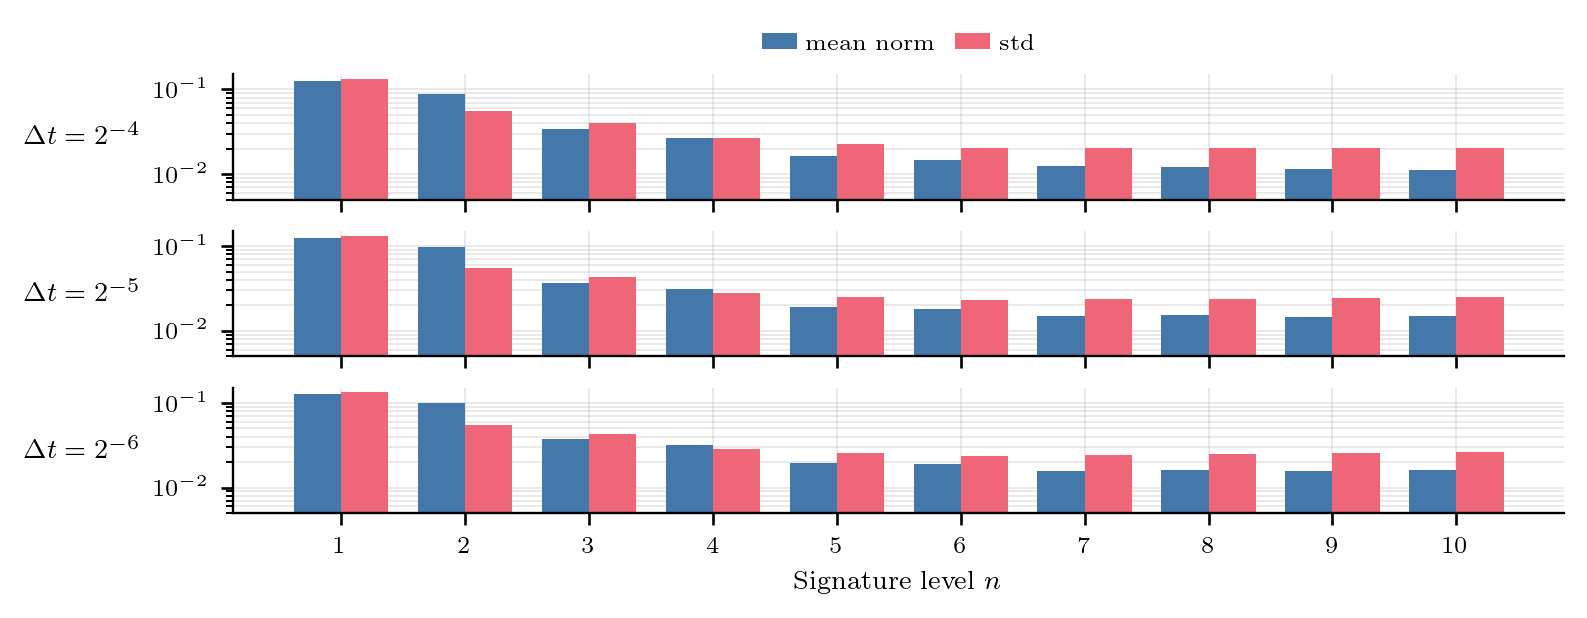

In [3]:
import sys
sys.path.insert(0, 'validation')
import plot_config  # applies rcParams
from plot_config import FULL_WIDTH, COLORS, savefig_fig
import matplotlib.pyplot as plt
from pathlib import Path

dt_values = df["dt"].drop_duplicates().to_list()[1:]  # skip coarsest
n_dt = len(dt_values)

ROW_HEIGHT = 0.82  # inches per row
fig, axes = plt.subplots(n_dt, 1, figsize=(FULL_WIDTH, ROW_HEIGHT * n_dt), sharex=True)

if n_dt == 1:
    axes = [axes]

bar_width = 0.38

for ax, dt in zip(axes, dt_values):
    g = df[df["dt"] == dt]
    x = g["level"].to_numpy()
    ax.bar(x - bar_width / 2, g["mean_norm"], width=bar_width, color=COLORS[0], label="mean norm")
    ax.bar(x + bar_width / 2, g["std"],       width=bar_width, color=COLORS[1], label="std")
    ax.set_yscale("log")
    ax.set_ylabel(rf"$\Delta t = {dt.strip('$')}$", rotation=0, ha="right", va="center")
    ax.grid(True, axis="y", which="both")
    ax.set_ylim(0.5e-2, 1.5e-1)

axes[-1].set_xlabel(r"Signature level $n$")
axes[-1].set_xticks(range(1, trunc + 1))
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.5), ncol=2, frameon=False)

out_path = Path('validation') / OUTPUT_DIR
out_path.mkdir(parents=True, exist_ok=True)
savefig_fig(fig, out_path / "signature_level_stats_by_dt", ["pdf", "png"])
plt.show()

## 1. Λ = 0 correctness check

When $\Lambda = 0$ the matrix exponential $e^{\Lambda \Delta t} = I$ for all $\Delta t$, and the
state-space recursion collapses to a plain iterated integral.  Concretely, with $Y_t = A X_t \in \mathbb{R}^m$,

$$
\mathrm{SSS}_{\Lambda=0}(X)^n \;=\; \mathrm{Sig}(Y)^n, \qquad n = 1, \ldots, N.
$$

We verify this to **float64 precision** (max absolute error $< 10^{-12}$) for several
$(q, R, m, d)$ configurations.

In [4]:
%run validation/validate_lambda0.py

 q  R  m  d  N      max_abs   max_scaled     mean_abs  mean_scaled
 1  1  2  2  1 1.387779e-16 1.387779e-16 4.813858e-17 4.813858e-17
 1  1  2  2  2 3.719247e-15 7.438494e-15 1.295808e-15 2.591616e-15
 1  1  2  2  3 3.719247e-15 9.700574e-15 1.298325e-15 2.596651e-15
 1  1  2  2  4 3.719247e-15 1.861011e-14 1.298325e-15 2.596651e-15
 1  1  2  2  5 3.719247e-15 1.861011e-14 1.298325e-15 2.596651e-15
 1  1  2  2  6 3.719247e-15 2.716577e-14 1.298325e-15 2.871467e-15
 1  1  2  2  7 3.719247e-15 4.173419e-14 1.298325e-15 2.977700e-15
 1  1  2  2  8 3.719247e-15 6.891948e-14 1.298325e-15 4.022435e-15
 1  1  2  2  9 3.719247e-15 1.055820e-13 1.298325e-15 4.679679e-15
 1  1  2  2 10 3.719247e-15 1.711674e-13 1.298325e-15 6.129603e-15
 3  2  2  2  1 2.220446e-16 2.220446e-16 5.702903e-17 5.702903e-17
 3  2  2  2  2 3.358425e-15 6.716849e-15 9.388276e-16 1.877655e-15
 3  2  2  2  3 3.358425e-15 9.034440e-15 9.388276e-16 1.877655e-15
 3  2  2  2  4 3.358425e-15 1.003364e-14 9.388276e-16 2.217073

## 2. Euler convergence

The exact FSSK is evaluated via a **matrix-exponential recursion** along the path grid.
An alternative is the **Euler scheme**: replace $e^{\Lambda \Delta t} \approx I + \Lambda \Delta t$
at each step.  This is first-order accurate, so refining the grid by a factor of 2 (one dyadic
level) should halve the error:

$$
\bigl\|\mathrm{SSS}_{\mathrm{Euler},k}(X) - \mathrm{SSS}_{\mathrm{exact}}(X)\bigr\|
\;=\; O(2^{-k}), \qquad k = 0, 1, 2, \ldots
$$

We fix the coarse grid ($J$ points, $d$-dimensional paths) and sweep dyadic refinement orders
$k = 0, \ldots, k_{\max}$.  For each setup $(q, R)$ and each signature level $n$ we plot

$$
n! \cdot \max_{\text{paths},\,\text{entries}} \bigl|S^n_{\mathrm{exact}} - S^n_{\mathrm{Euler},k}\bigr|
$$

against $k$ on a log scale.  A slope of $-1$ confirms first-order convergence.

In [5]:
# -- Parameters (edit here) --
J          = 16    # coarse path grid points (J-1 increments)
N          = 7     # signature truncation level
m          = 3     # latent-path dimension
d          = 3     # input-path dimension
n_paths    = 128   # batch size
max_dyadic = 8     # sweep dyadic orders 0 ... max_dyadic
path_seed  = 20226 # RNG seed for path generation
setups = [
    {"q": 1, "R": 1, "seed": 412},
    {"q": 2, "R": 2, "seed": 431},
    {"q": 4, "R": 3, "seed": 144},
]

In [15]:
import subprocess, sys, json
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

script = Path('validation/validate_euler_convergence_demo.py').resolve()
result = subprocess.run(
    [
        sys.executable, str(script),
        '--J',          str(J),
        '--N',          str(N),
        '--m',          str(m),
        '--d',          str(d),
        '--n-paths',    str(n_paths),
        '--max-dyadic', str(max_dyadic),
        '--path-seed',  str(path_seed),
        '--setups',     json.dumps(setups),
        '--output-dir', str(Path('validation') / OUTPUT_DIR),
    ],
    cwd=str(script.parent.parent),
    capture_output=False,
)
if result.returncode != 0:
    raise RuntimeError(
        f'validate_euler_convergence_demo.py failed with exit code {result.returncode}'
    )


── q=1, R=1 ──────────────────────────────
  dyadic=0  lvl1=1.43e-01  lvl2=3.45e+00  lvl3=2.37e+01  lvl4=1.69e+02  lvl5=1.02e+03  lvl6=8.37e+03  lvl7=7.62e+04
  dyadic=1  lvl1=6.87e-02  lvl2=1.62e+00  lvl3=1.12e+01  lvl4=8.33e+01  lvl5=5.39e+02  lvl6=4.50e+03  lvl7=3.87e+04
  dyadic=2  lvl1=3.37e-02  lvl2=7.89e-01  lvl3=5.83e+00  lvl4=4.17e+01  lvl5=2.80e+02  lvl6=2.44e+03  lvl7=2.18e+04
  dyadic=3  lvl1=1.67e-02  lvl2=3.89e-01  lvl3=3.00e+00  lvl4=2.09e+01  lvl5=1.44e+02  lvl6=1.27e+03  lvl7=1.17e+04
  dyadic=4  lvl1=8.31e-03  lvl2=1.93e-01  lvl3=1.52e+00  lvl4=1.05e+01  lvl5=7.35e+01  lvl6=6.46e+02  lvl7=6.04e+03
  dyadic=5  lvl1=4.15e-03  lvl2=9.62e-02  lvl3=7.63e-01  lvl4=5.23e+00  lvl5=3.71e+01  lvl6=3.26e+02  lvl7=3.07e+03
  dyadic=6  lvl1=2.07e-03  lvl2=4.80e-02  lvl3=3.83e-01  lvl4=2.62e+00  lvl5=1.86e+01  lvl6=1.64e+02  lvl7=1.55e+03
  dyadic=7  lvl1=1.04e-03  lvl2=2.40e-02  lvl3=1.92e-01  lvl4=1.31e+00  lvl5=9.34e+00  lvl6=8.20e+01  lvl7=7.77e+02
  dyadic=8  lvl1=5.17e-04  l

-- Convergence rates (fitted log2 slope per setup x level) --


,label,q,R,level,slope,intercept_log2
0,"q=1, R=1",1,1,1,-1.010722,-2.850177
1,"q=1, R=1",1,1,2,-1.016714,1.720783
2,"q=1, R=1",1,1,3,-0.987597,4.533373
3,"q=1, R=1",1,1,4,-1.000217,7.387488
4,"q=1, R=1",1,1,5,-0.973387,10.054442
5,"q=1, R=1",1,1,6,-0.963044,13.128552
6,"q=1, R=1",1,1,7,-0.948755,16.275184
7,"q=2, R=2",2,2,1,-1.006033,-3.990051
8,"q=2, R=2",2,2,2,-1.014118,1.356248
9,"q=2, R=2",2,2,3,-0.992118,4.132002



-- Scaled max errors  n! * max|S^n_exact - S^n_Euler| --


label         q=1, R=1                                                \
level                1         2          3           4            5   
dyadic_order                                                           
0             0.142708  3.446951  23.749900  168.937307  1019.877996   
1             0.068680  1.623598  11.236145   83.270255   539.496881   
2             0.033712  0.788801   5.826667   41.675293   279.549125   
3             0.016704  0.388875   2.995812   20.877362   144.075198   
4             0.008315  0.193083   1.517261   10.451689    73.464895   
5             0.004148  0.096206   0.763318    5.229447    37.091689   
6             0.002072  0.048019   0.382812    2.615665    18.635923   
7             0.001035  0.023989   0.191692    1.308073     9.340512   
8             0.000517  0.011989   0.095917    0.654097     4.675898   

label                                    q=2, R=2                       ...  \
level                   6             7         1         2          3  ...   
dyadic_order                                                            ...   
0             8371.317386  76205.699715  0.063947  2.658188  17.102562  ...   
1             4497.835218  38675.356978  0.031300  1.264176   8.848360  ...   
2             2444.689423  21771.960060  0.015488  0.616916   4.482545  ...   
3             1269.332953  11673.784914  0.007704  0.304787   2.254119  ...   
4              646.164235   6036.879682  0.003842  0.151490   1.130067  ...   
5              325.925171   3068.786952  0.001919  0.075521   0.565760  ...   
6              163.669414   1547.022240  0.000959  0.037705   0.283059  ...   
7               82.010922    776.673447  0.000479  0.018838   0.141574  ...   
8               41.049453    389.127941  0.000240  0.009416   0.070798  ...   

label                                                q=4, R=3            \
level                  5            6             7         1         2   
dyadic_order                                                              
0             431.818630  1951.347842  11370.006035  0.087120  2.647025   
1             254.297097  1347.548618   7707.831477  0.042277  1.260746   
2             138.221524   786.705676   4607.904994  0.020834  0.615689   
3              72.825745   424.079819   2517.428837  0.010343  0.304290   
4              37.354596   220.034039   1315.352052  0.005153  0.151271   
5              18.914265   112.054629    672.252810  0.002572  0.075418   
6               9.516561    56.541602    339.823315  0.001285  0.037655   
7               4.773160    28.399984    170.842508  0.000642  0.018814   
8               2.390303    14.232364     85.654797  0.000321  0.009404   

label                                                                      
level                 3          4           5            6             7  
dyadic_order                                                               
0             18.492453  98.491411  600.070353  3489.257628  21496.635374  
1              9.034869  52.504758  345.418916  2274.564431  13664.154756  
2              4.464671  27.524194  184.206154  1288.687901   8236.592025  
3              2.219179  14.121846   94.984384   684.449066   4538.660684  
4              1.106306   7.155292   48.212741   352.523907   2380.966695  
5              0.552333   3.601747   24.286496   178.870353   1219.224217  
6              0.275962   1.806960   12.188275    90.091434    616.902102  
7              0.137930   0.905009    6.105394    45.210298    310.286695  
8              0.068952   0.452888    3.055511    22.646359    155.603905  

[9 rows x 21 columns]

euler_conv_demo_q_1_R_1


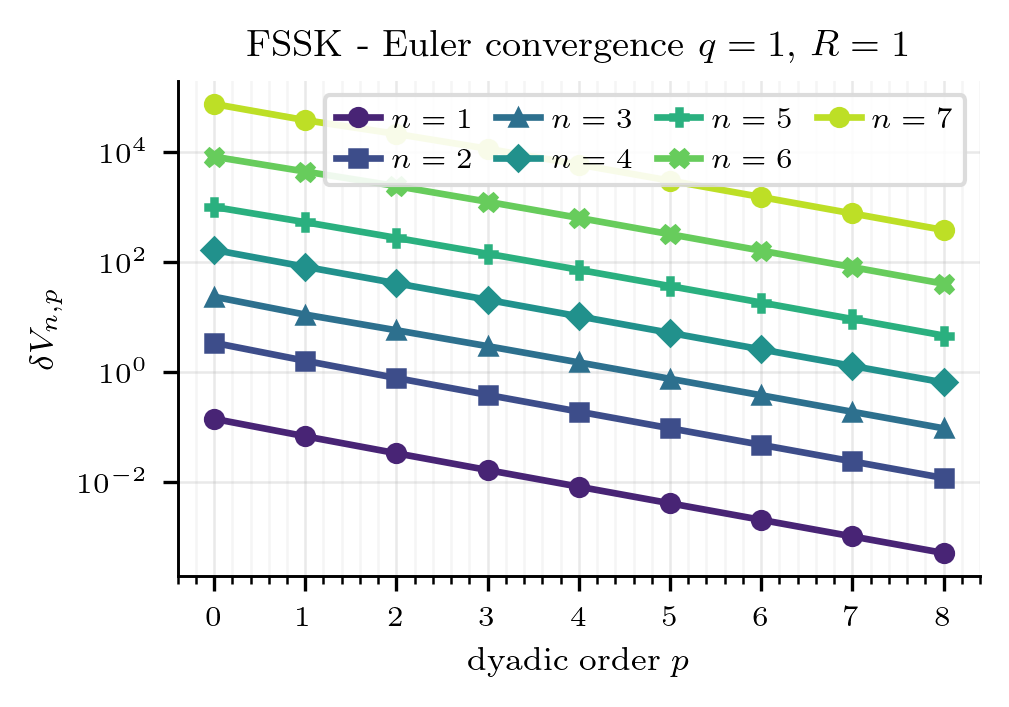

euler_conv_demo_q_2_R_2


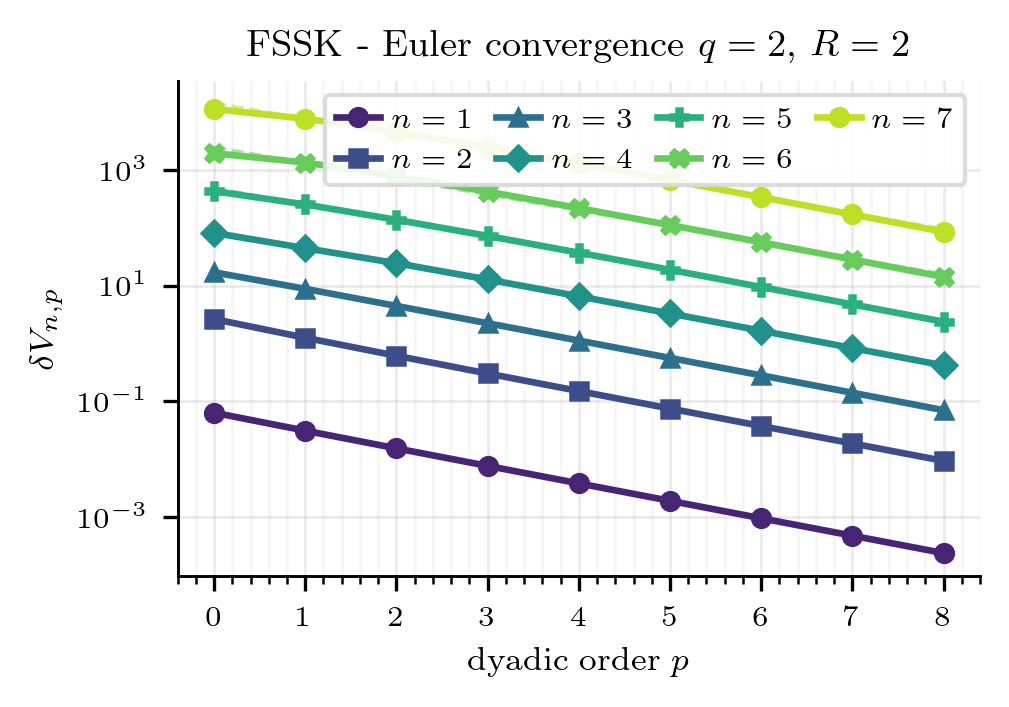

euler_conv_demo_q_4_R_3


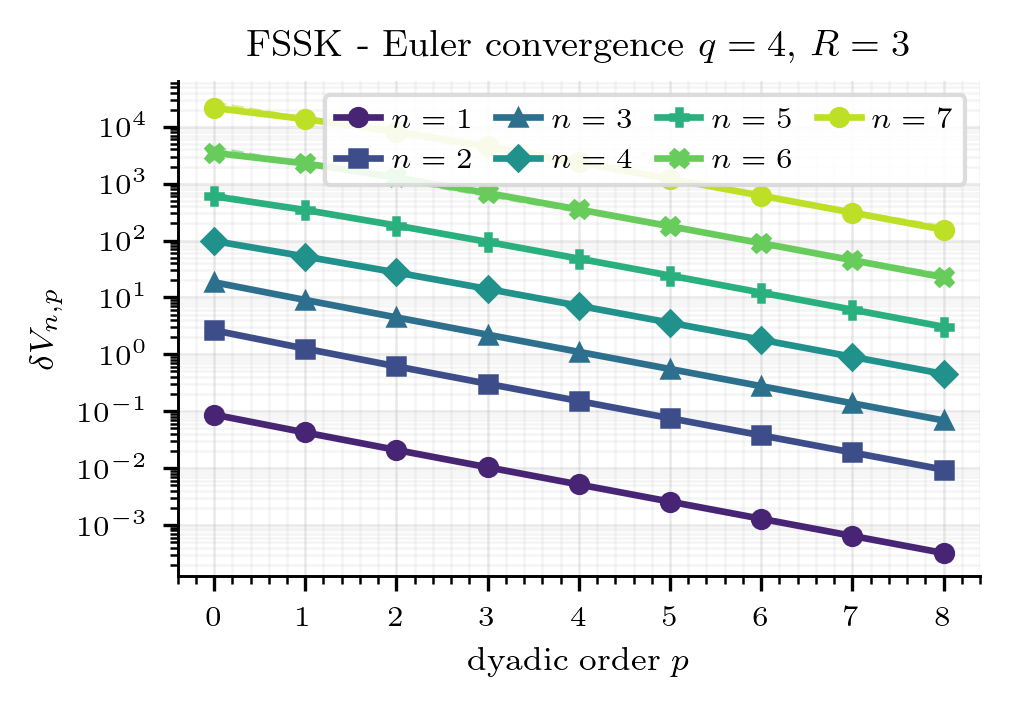

In [16]:
from pathlib import Path
from IPython.display import display, Image
import pandas as pd

out = Path('validation') / OUTPUT_DIR

print('-- Convergence rates (fitted log2 slope per setup x level) --')
display(pd.read_csv(out / 'euler_conv_demo_rates.csv'))

print('\n-- Scaled max errors  n! * max|S^n_exact - S^n_Euler| --')
df_err = pd.read_csv(out / 'euler_conv_demo_errors.csv')
display(df_err.pivot_table(index='dyadic_order', columns=['label', 'level'],
                           values='scaled_max_error'))

for png in sorted(out.glob('euler_conv_demo_*.png')):
    print(png.stem)
    display(Image(filename=str(png)))

## 3. FLOP scaling

The dominant cost of the exact FSSK recursion is the shuffle-product accumulation over
multi-indices.  The predicted work per kernel evaluation is

$$
W_q \;=\; (J-1)\,R^2\,
\begin{cases}
m^N & q = 1, \\
N\,m^N & q > 1.
\end{cases}
$$

We sweep over $(J, N, m, R, q)$ configurations, record the **XLA FLOP count** via
`jax.xla_computation`, and verify that $\mathrm{FLOPs} \propto W_q$ on log-log axes.

In [8]:
RUN_REGIME = "MEDIUM"   # SMALL | MEDIUM | LARGE

In [9]:
import subprocess, sys
from pathlib import Path

script = Path("validation/sweep_flop_scaling.py").resolve()
result = subprocess.run(
    [sys.executable, str(script), "--regime", RUN_REGIME],
    cwd=str(script.parent),
)
if result.returncode != 0:
    raise RuntimeError(f"sweep_flop_scaling.py failed with exit code {result.returncode}")

Regime          : MEDIUM
Total configs   : 1200

Design summary:
  q   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  J   : [np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(41), np.int64(44), np.int64(53), np.int64(54), np.int64(59), np.int64(62), np.int64(63), np.int64(66), np.int64(67), np.int64(68), np.int64(70), np.int64(71), np.int64(76), np.int64(80), np.int64(82), np.int64(84), np.int64(86), np.int64(88), np.int64(91), np.int64(94), np.int64(95), np.int64(97), np.int64(100), np.int64(102), np.int64(104), np.int64(105), np.int64(106), np.int64(113), np.int64(115), np.int64(118), np.int64(119), np.int64(120), np.int64(121), np.int64(127), np.int64(132), np.int64(138), np.int64(140), np.int64(143), np.int64(144), np.int64(146), np.int64(147), np.int64(148), np.int64(151), np.int64(153), np.int64(157), np.int64(167), np.int64(169), np.int64(173), np.int64(175), np.int64(178), np.int64(189), np.int64(191), np.int64(194), np.int64(195), np.int6

Loaded rows     : 1200
Valid FLOP rows : 1200
q values        : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
J values        : [np.int64(32), np.int64(33), np.int64(34), np.int64(36), np.int64(37), np.int64(41), np.int64(44), np.int64(53), np.int64(54), np.int64(59), np.int64(62), np.int64(63), np.int64(66), np.int64(67), np.int64(68), np.int64(70), np.int64(71), np.int64(76), np.int64(80), np.int64(82), np.int64(84), np.int64(86), np.int64(88), np.int64(91), np.int64(94), np.int64(95), np.int64(97), np.int64(100), np.int64(102), np.int64(104), np.int64(105), np.int64(106), np.int64(113), np.int64(115), np.int64(118), np.int64(119), np.int64(120), np.int64(121), np.int64(127), np.int64(132), np.int64(138), np.int64(140), np.int64(143), np.int64(144), np.int64(146), np.int64(147), np.int64(148), np.int64(151), np.int64(153), np.int64(157), np.int64(167), np.int64(169), np.int64(173), np.int64(175), np.int64(178), np.int64(189), np.int64(191), np.int64(194), np.int64(195), np.int

,q,n_points,W_min,W_max,flops_min,flops_max,pearson_log,spearman_log
0,1,300,492075.0,8.150337e+08,8040222.0,2.231371e+10,0.998223,0.997874
1,2,300,2460375.0,8.207575e+09,22832361.0,9.364167e+10,0.999464,0.999350
2,3,300,2460375.0,8.207575e+09,44729901.0,2.630972e+11,0.998327,0.998168
3,4,300,2460375.0,8.207575e+09,83628531.0,7.528155e+11,0.996391,0.996471


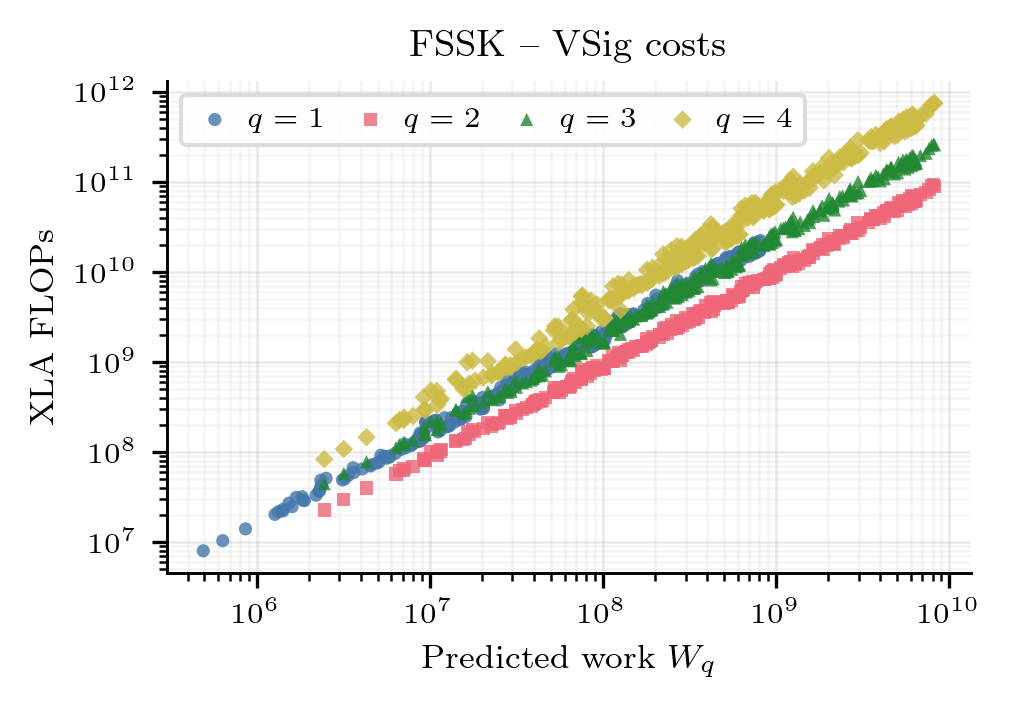

In [10]:
import subprocess, sys
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

tag = RUN_REGIME.lower()

script = Path('validation/analyse_flop_scaling.py').resolve()
result = subprocess.run(
    [sys.executable, str(script), '--regime', RUN_REGIME],
    cwd=str(script.parent.parent),
)
if result.returncode != 0:
    raise RuntimeError(f'analyse_flop_scaling.py failed with exit code {result.returncode}')

out_dir = Path('validation/validation_outputs')

print('FLOP scaling summary (Spearman / Pearson log-correlation per q)')
display(pd.read_csv(out_dir / f'fssk_flop_scaling_{tag}_summary.csv'))

display(Image(filename=str(out_dir / f'fssk_flop_scaling_{tag}_xla_flops_vs_predicted_work.png')))

## 4. Wall-clock and CPU time vs. predicted work $W_q$

The theoretical cost model predicts that the hot-path runtime should scale as

$$
T_{\mathrm{hot}} \;\approx\; C_q \cdot W_q(J, R; N),
\qquad
W_q =
(J-1)\,R^2
\begin{cases}
m^N & q = 1,\\
N\,m^N & q > 1.
\end{cases}
$$

We verify this empirically by sweeping $(J, N, R, q, m)$ with the regime sampler,
timing the hot FSSK evaluation with `time.perf_counter` (wall) and
`time.process_time_ns` (CPU), and plotting both against $W_q$ on log-log axes.
A slope of $1$ on the log-log scale confirms the linear scaling prediction.

In [6]:
# -- Parameters (edit here) --
RUN_REGIME_TIMING = "MEDIUM"   # SMALL | MEDIUM | LARGE
TIMING_REPEATS    = None        # None = use regime default; or e.g. 5

In [ ]:
import subprocess, sys
from pathlib import Path

script = Path("validation/run_timings.py").resolve()
cmd = [sys.executable, str(script), "--regime", RUN_REGIME_TIMING]
if TIMING_REPEATS is not None:
    cmd += ["--repeats", str(TIMING_REPEATS)]

result = subprocess.run(cmd, cwd=str(script.parent))
if result.returncode != 0:
    raise RuntimeError(f"run_timings.py failed with exit code {result.returncode}")

Regime          : MEDIUM
n_repeats       : 5
Total runs      : 1200

family
q1      300
qgt1    900

[001/1200]    q1 | q=1  J=529  R=8  N=7
[002/1200]  qgt1 | q=2  J=529  R=8  N=7
[003/1200]  qgt1 | q=3  J=529  R=8  N=7
[004/1200]  qgt1 | q=4  J=529  R=8  N=7
[005/1200]    q1 | q=1  J=324  R=9  N=7
[006/1200]  qgt1 | q=2  J=324  R=9  N=7
[007/1200]  qgt1 | q=3  J=324  R=9  N=7
[008/1200]  qgt1 | q=4  J=324  R=9  N=7
[009/1200]    q1 | q=1  J=913  R=7  N=7
[010/1200]  qgt1 | q=2  J=913  R=7  N=7
[011/1200]  qgt1 | q=3  J=913  R=7  N=7
[012/1200]  qgt1 | q=4  J=913  R=7  N=7
[013/1200]    q1 | q=1  J=682  R=12  N=5
[014/1200]  qgt1 | q=2  J=682  R=12  N=5
[015/1200]  qgt1 | q=3  J=682  R=12  N=5
[016/1200]  qgt1 | q=4  J=682  R=12  N=5
[017/1200]    q1 | q=1  J=276  R=9  N=8
[018/1200]  qgt1 | q=2  J=276  R=9  N=8
[019/1200]  qgt1 | q=3  J=276  R=9  N=8
[020/1200]  qgt1 | q=4  J=276  R=9  N=8
[021/1200]    q1 | q=1  J=583  R=8  N=7
[022/1200]  qgt1 | q=2  J=583  R=8  N=7
[023/1200]  qgt

Loaded 150 rows from validation/validation_outputs/fssk_exact_scaling_timings_small.pkl
q distribution:


,count
q,
1,50
2,50
3,50


  Saved: validation/validation_outputs/fssk_wall_vs_work_small.pdf
  Saved: validation/validation_outputs/fssk_wall_vs_work_small.png


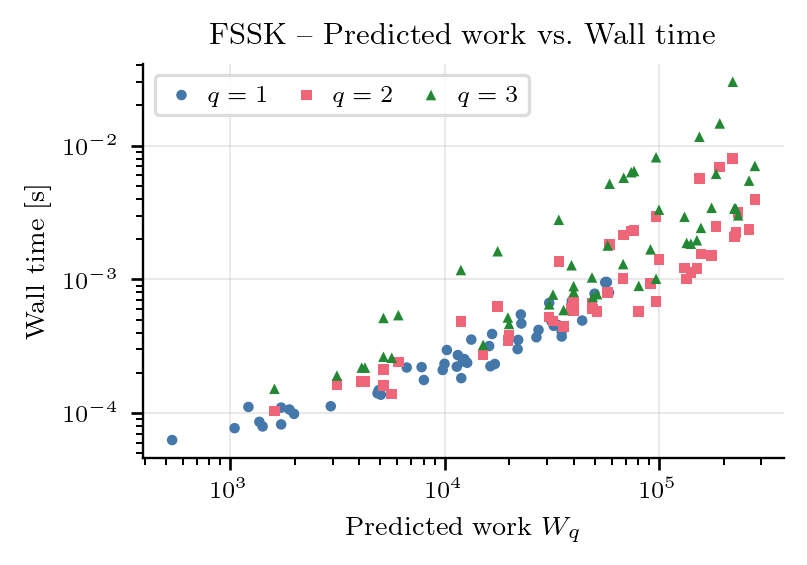


Timing summary (per q, wall time vs W_q):


,q,n_points,W_min,W_max,wall_min,wall_max,spearman_log,pearson_log
0,1,50,536,58400,0.000063,0.000959,0.9629,0.9571
1,2,50,1608,279552,0.000104,0.008045,0.8922,0.8963
2,3,50,1608,279552,0.000152,0.030058,0.8410,0.8332


In [5]:
import sys
sys.path.insert(0, 'validation')
import plot_config
from plot_config import HALF_WIDTH, COLORS, MARKERS, SCATTER_SIZE, savefig_fig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display
from scipy.stats import spearmanr, pearsonr

tag     = RUN_REGIME_TIMING.lower()
out_dir = Path('validation/validation_outputs')
pkl     = out_dir / f'fssk_exact_scaling_timings_{tag}.pkl'

df = pd.read_pickle(pkl)
for col in ['q', 'J', 'R', 'N', 'm', 'wall_hot_median_s', 'cpu_hot_median_s']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=['q', 'J', 'R', 'N', 'm', 'wall_hot_median_s']).copy()

df['W_q'] = np.where(
    df['q'] == 1,
    (df['J'] - 1) * df['R']**2 * df['m']**df['N'],
    (df['J'] - 1) * df['R']**2 * df['N'] * df['m']**df['N'],
)

print(f'Loaded {len(df)} rows from {pkl}')
print('q distribution:')
display(df['q'].value_counts().sort_index().rename('count').to_frame())

qs = sorted(df['q'].unique())

sub = df.dropna(subset=['wall_hot_median_s'])
fig, ax = plt.subplots(figsize=(HALF_WIDTH, HALF_WIDTH / 1.45))
for i, q in enumerate(qs):
    g = sub[sub['q'] == q]
    ax.scatter(
        g['W_q'], g['wall_hot_median_s'],
        color=COLORS[i % len(COLORS)],
        marker=MARKERS[i % len(MARKERS)],
        s=SCATTER_SIZE, edgecolors='none', label=f'$q={q}$',
    )
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'Predicted work $W_q$')
ax.set_ylabel(r'Wall time [s]')
ax.set_title(r'FSSK -- Predicted work vs.\ Wall time')
ax.legend(ncol=len(qs), loc='upper left', frameon=True)
savefig_fig(fig, out_dir / f'fssk_wall_vs_work_{tag}', ['pdf', 'png'])
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for q, g in sub.groupby('q'):
    lW = np.log(g['W_q'])
    lT = np.log(g['wall_hot_median_s'])
    sp, _ = spearmanr(lW, lT)
    pe, _ = pearsonr(lW, lT)
    rows.append(dict(q=q, n_points=len(g),
                     W_min=g['W_q'].min(), W_max=g['W_q'].max(),
                     wall_min=g['wall_hot_median_s'].min(),
                     wall_max=g['wall_hot_median_s'].max(),
                     spearman_log=round(sp, 4), pearson_log=round(pe, 4)))
df_summary = pd.DataFrame(rows)
df_summary.to_csv(out_dir / f'fssk_timing_summary_{tag}.csv', index=False)
print('\nTiming summary (per q, wall time vs W_q):')
display(df_summary)